# 🌟 COSMIC v0.0.1 - Compatibilidad Automática

**Este notebook ha sido actualizado para COSMIC v0.0.1**

## ✨ Mejoras Disponibles
- **Estructura modular**: `cosmic.core`, `cosmic.io`, `cosmic.preprocess`, `cosmic.analysis`
- **Imports modernos**: Específicos y organizados
- **API mejorada**: Mejor manejo de errores y configuración
- **Compatibilidad total**: El código existente sigue funcionando

## 🔄 Migración Opcional
Para usar las nuevas funcionalidades:
```python
# Nuevo (recomendado)
from cosmic.analysis.analyzer import ClusterAnalyzer
from cosmic.core.clustering import Clustering
from cosmic.io.loader import DataLoader

# Legacy (sigue funcionando)
from COSMIC import ClusterAnalyzer
from clustering import HDBSCANClustering
from data_loader import DataLoader
```

📚 **Documentación**: `/docs/reference/NOTEBOOK_MIGRATION_GUIDE.md`

In [20]:
import numpy as np
from astropy.table import QTable
from astropy.visualization import quantity_support
import astropy.units as u
import matplotlib.pyplot as plt
import pymc as pm
quantity_support();
%config InlineBackend.figure_format ='retina'

In [21]:
rng = np.random.default_rng(seed=42)
N = 256

sim_data = QTable()

# we generate the true distances from a Gaussian and convert to parallax values:
true_sc_dist = 500 * u.pc
true_sc_std = 8.7 * u.pc
true_sc_star_dist = (
    rng.normal(true_sc_dist.value, true_sc_std.value, size=N) * true_sc_dist.unit
)
sim_data["parallax"] = true_sc_star_dist.to(u.mas, u.parallax())

# heteroscedastic noise (i.e. each star has its own error bar):
sim_data["parallax_error"] = (10 ** rng.uniform(-2, -1.0, size=N)) * u.mas

# now we have to "observe" the true parallaxes with the generated uncertainties:
sim_data["parallax"] = (
    rng.normal(sim_data["parallax"].value, sim_data["parallax_error"].value)
    * sim_data["parallax"].unit
)

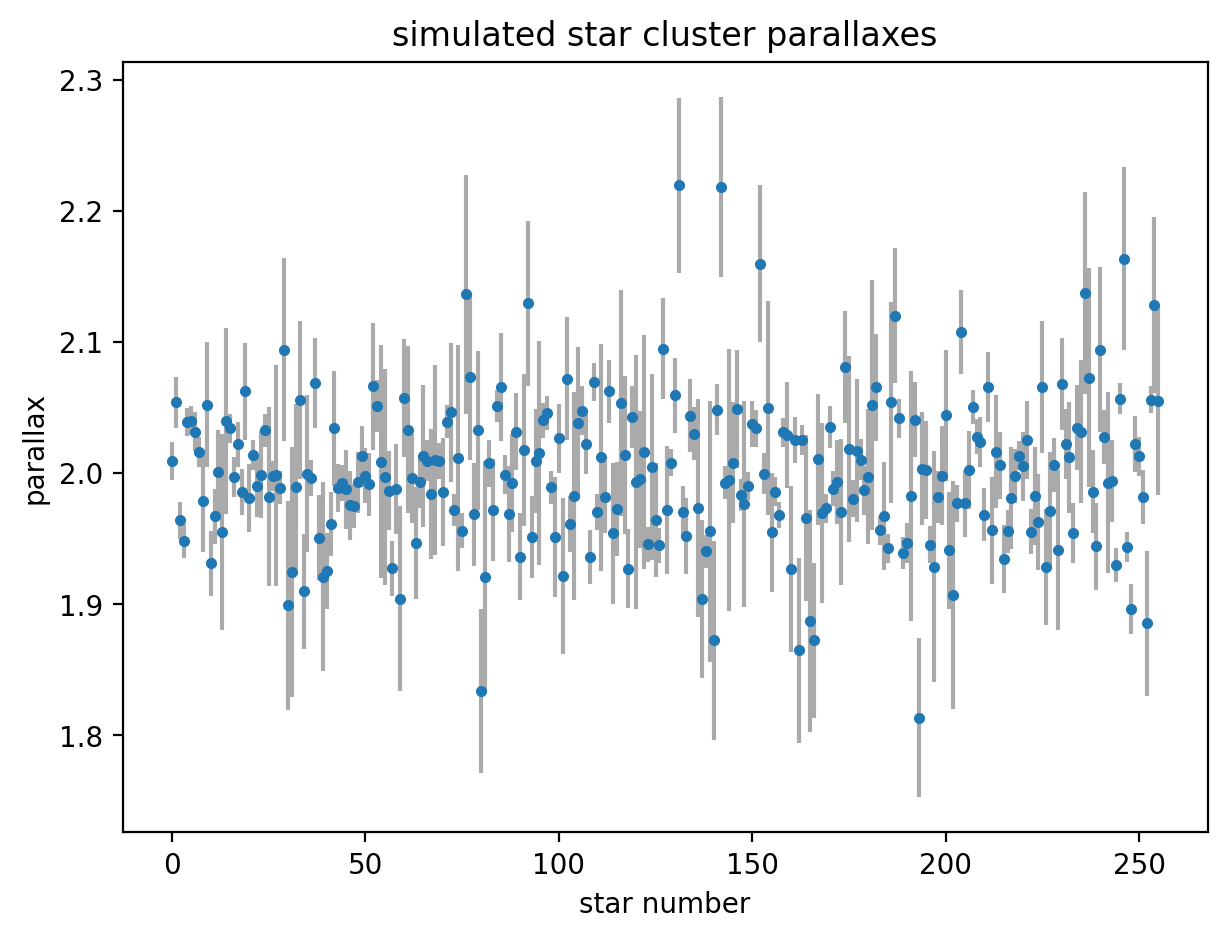

In [22]:
plt.figure(figsize=(7, 5))
plt.errorbar(
    np.arange(len(sim_data)),
    sim_data["parallax"].value,
    yerr=sim_data["parallax_error"].value,
    ls="none",
    marker="o",
    markersize=3,
    ecolor="#aaa",
)
plt.title("simulated star cluster parallaxes")
plt.xlabel("star number")
plt.ylabel("parallax");

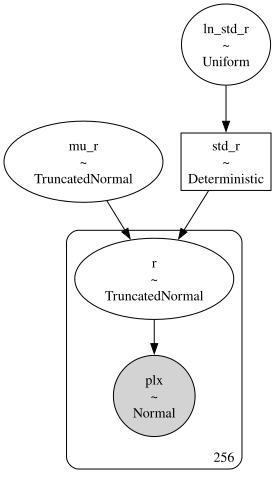

In [23]:
with pm.Model() as plx_model:
    # This is the (hyper)prior on the mean distance to the star cluster. Let's assume
    # that we have some prior knowledge about the distance to this cluster, and so we
    # set a broad normal distribution prior on its distance. However, we know that
    # distances can't be negative, so we use a truncated normal distribution (truncated
    # to values > 0) instead:
    mu_r = pm.TruncatedNormal("mu_r", mu=1.0, sigma=2.0, lower=0, upper=np.inf)

    # This is the (hyper)prior on ln(sigma), the log of the standard deviation of the
    # star cluster's distance (i.e. the physical size of the cluster along the line of
    # sight).
    ln_std_r = pm.Uniform("ln_std_r", -8, 0)

    # We will sample over ln(sigma), but we need the value of sigma (standard deviation)
    # to plug into the model we use for the cluster. We can transform the parameter to
    # a new un-logged value, but we need to tell pymc that this is not a new random
    # variable: the relationship between these parameters is a deterministic tranform
    std_r = pm.Deterministic("std_r", pm.math.exp(ln_std_r))

    # With parameters to represent the cluster mean distance and standard deviation,
    # we can now define the model for the distances to each star. Here we will again use
    # a truncated normal distribution (r>=0). Note that we specify the "shape" of this
    # parameter: This tells pymc to expect that we will have as many parameter values
    # as we have len(sim_data).
    # This line is equivalent to p(r | mu_r, sigma_r) in the math above
    r = pm.TruncatedNormal("r", mu_r, std_r, shape=len(sim_data), lower=0, upper=np.inf)

    # Finally, with the model-predicted individual stellar distances, we need to define
    # the relationship between our model and our data (i.e. the parallax measurements).
    # We assume that our parallax uncertainties are Gaussian, so we set up another
    # Normal distribution (not truncated) with an expression for the model predicted
    # parallaxes (1/r), and pass in the observed parallaxes with the "observed" keyword.
    # This line is equivalent to p(parallax | r) in the math above:
    pm.Normal(
        "plx",
        1 / r,
        observed=sim_data["parallax"].to_value(u.mas),
        sigma=sim_data["parallax_error"].to_value(u.mas),
    )

# Let's visualize the graphical model for this model and compare to the one above:
pm.model_to_graphviz(plx_model)

In [24]:
inv_var = 1 / sim_data["parallax_error"] ** 2
est_mean_plx = np.sum(sim_data["parallax"] * inv_var) / np.sum(inv_var)
est_mean_r = est_mean_plx.to_value(u.kpc, u.parallax())

In [25]:
with plx_model:
    samples = pm.sample(
        tune=2000,
        draws=1000,
        initvals={
            "mu_r": est_mean_r,
            "ln_std_r": -3.0,
            "r": np.full(len(sim_data), est_mean_r),
        },
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_r, ln_std_r, r]


Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 3 seconds.


In [27]:
import arviz as az
az.summary(samples, var_names=["~r"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_r,0.500,0.001,0.499,0.502,0.000,0.000,5324.0,3298.0,1.0
ln_std_r,-4.788,0.077,-4.933,-4.645,0.002,0.001,1630.0,1957.0,1.0
std_r,0.008,0.001,0.007,0.010,0.000,0.000,1630.0,1957.0,1.0


<xarray.DataArray ()> Size: 8B
array(0.06675717)

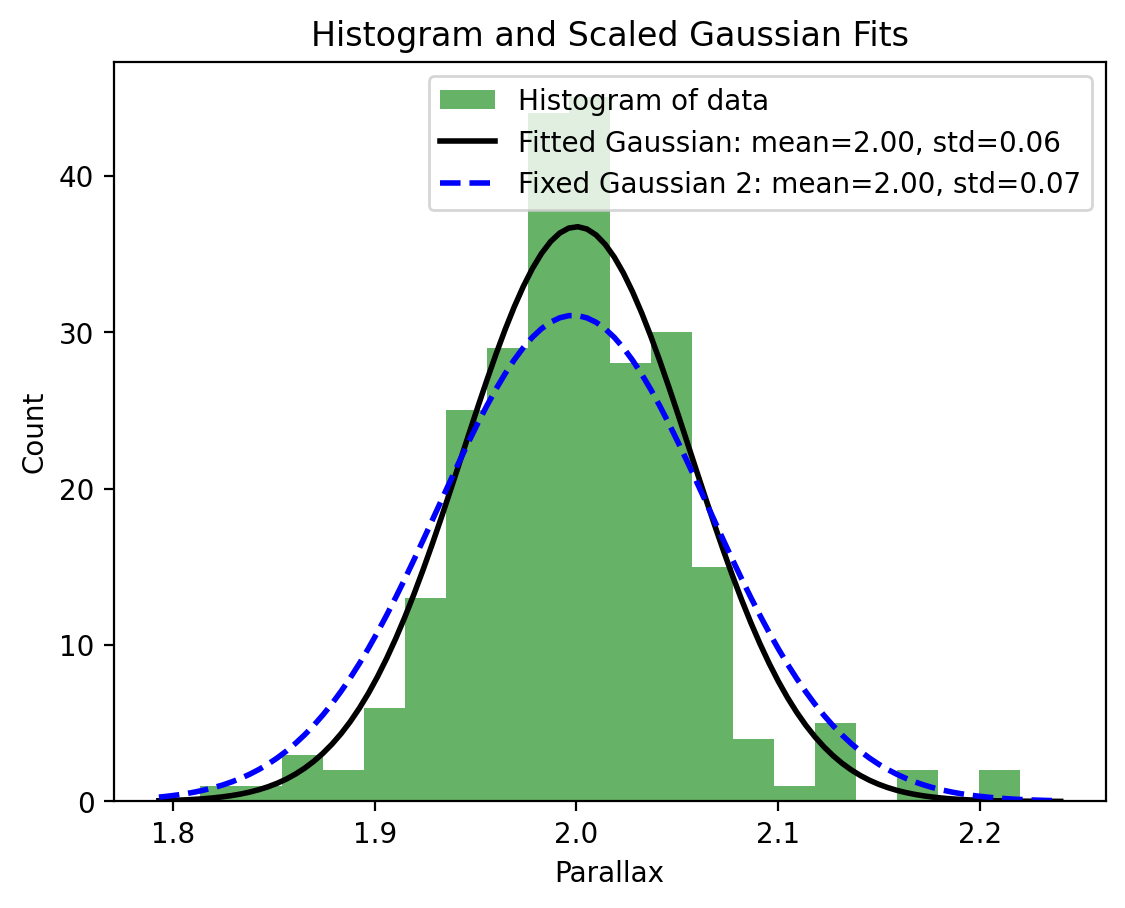

In [44]:

fixed_mean2 = 1/samples.posterior['mu_r'].mean()  # Example second fixed mean
fixed_std2 = 1/((samples.posterior['mu_r'].mean()- samples.posterior['std_r'].mean())) - 1/((samples.posterior['std_r'].mean()+samples.posterior['mu_r'].mean()))

# Plot the histogram of the data
n, bins, patches = plt.hist(data, bins='auto', alpha=0.6, color='g', label='Histogram of data', density=False)
# Calculate bin width
bin_width = np.diff(bins)[0]
# Calculate scaling factor for Gaussian PDFs
scaling_factor = len(data) * bin_width

# Plot the fitted Gaussian, scaled to match the histogram
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std) * scaling_factor  # Scale the PDF by the scaling factor
plt.plot(x, p, 'k', linewidth=2, label=f'Fitted Gaussian: mean={mu:.2f}, std={std:.2f}')

# Plot the second fixed Gaussian, scaled to match the histogram
p_fixed2 = norm.pdf(x, fixed_mean2, fixed_std2) * scaling_factor
plt.plot(x, p_fixed2, 'b--', linewidth=2, label=f'Fixed Gaussian 2: mean={fixed_mean2:.2f}, std={fixed_std2:.2f}')